In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import plotting_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

import diagnostic_utils

importlib.reload(diagnostic_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'diagnostic_utils' from '/home/emily_zuetell/projects/poreallas/analysis/diagnostic_utils.py'>

In [2]:
load_dotenv()

EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_PARSED_FORECAST_URI"]

In [3]:
# Projection Effects
load_dotenv()
# Baseline period for Impact
effect = xr.open_datatree(EFFECTS_URI, consolidated=False)
BASELINE_PERIOD = analysis_utils.get_baseline_period(effect, years=30)
# Define Forecast Months
FC_MONTHS = [9, 10, 11, 12, 1, 2]
FC_PERIOD = slice("2026-09-01", "2027-02-28")

config = analysis_utils.ImpactConfig( version = "v260910",
                                     baseline_period=BASELINE_PERIOD, 
                                     polygons_path= os.environ["POREALLAS_REGIONS_POLYGONS_URI"],
                                     socioeconomics_path= os.environ["POREALLAS_SOCIOECONOMICS_URI"],
                                     rate=True, 
                                     months = FC_MONTHS,
                                     hotonly = "net", 
                                     age_weight= False,
                                     dims = ['number', 'sample'])

In [ ]:
def bin_edges(tas_bin):
    # Standardize bin edges for discrete plotting
    tas_bin = np.asarray(tas_bin)
    return np.append(tas_bin, tas_bin[-1] + np.diff(tas_bin)[-1])


def _flat(da):
    # Flatten and check xarray
    v = np.asarray(da).ravel()
    return v[np.isfinite(v)]

In [ ]:
## Climate Data Processing ##
def select_climate(forecast, reanalysis, region, pad=3):
    # Subset climate data
    fc = forecast.sel(region=region)
    era5 = reanalysis.sel(region=region)
    vals = np.concatenate([_flat(fc), _flat(era5)])
    return dict(
        forecast=fc,
        era5=era5,
        n_members=fc.sizes["number"],
        n_years=np.unique(era5.time.dt.year).size,
        xlim=(vals.min() - pad, vals.max() + pad),
    )


def plot_climate_hist(ax, clim, edges):
    # Plot climate histograms
    # Weighted for "days per month" across ERA5 years and forecast members
    for key, n, color, label in [("era5", clim["n_years"], b_color, "ERA5"),
                                 ("forecast", clim["n_members"], f_color, "Forecast")]:
        v = _flat(clim[key])
        ax.hist(v, bins=edges, weights=np.full(v.size, 1 / n),
                alpha=0.5, color=color, label=label)
    ax.set_xlim(*clim["xlim"])

In [ ]:
## Response Curve ##
def select_betas(betas, mmt, region, age_cohort="age65plus"):
    # Subset response curve
    b = betas.sel(region=region, age_cohort=age_cohort).transpose("sample", "tas_bin")
    return dict(
        samples=b.values,                       # (sample, tas_bin)
        tas_bin=b["tas_bin"].values,
        mmt=mmt.sel(region=region, age_cohort=age_cohort).mean("sample").item(),
    )


def plot_response(ax, beta, ylim=(0, 10)):
    # Plot response curve and samples
    x, s = beta["tas_bin"], beta["samples"]
    # samples
    ax.step(x, s.T, where="pre", color=r_color, lw=0.5, alpha=0.15)
    # Average gamma sample
    ax.step(x, np.nanmean(s, axis=0), where="pre", color=r_color, lw=2, label="Response curve")
    # MMT
    ax.axvline(beta["mmt"], color=r_color, lw=1, label="MMT")
    ax.set_ylim(*ylim)
    ax.spines["top"].set_visible(False)

In [ ]:
## CDF ##
def compute_cdf(clim, beta, q=(5, 95)):
    # CDF and Uncertainty Range
    edges = bin_edges(beta["tas_bin"])
    out = {"x": beta["tas_bin"]}
    for key, n in [("era5", clim["n_years"]), ("forecast", clim["n_members"])]:
        counts, _ = np.histogram(_flat(clim[key]), bins=edges)
        # Cumulative mortality rate = response curve * histogram / num. samples
        cdf = np.cumsum(beta["samples"] * counts / n, axis=1)   # (sample, tas_bin)
        out[key] = dict(
            mean=np.nanmean(cdf, axis=0),
            lo=np.nanpercentile(cdf, q[0], axis=0),
            hi=np.nanpercentile(cdf, q[1], axis=0),
        )
    # Log for ylim
    out["max"] = max(out["era5"]["hi"].max(), out["forecast"]["hi"].max())
    return out

def plot_cdf(ax, cdf):
# Add CDF for forecast and era5 to plot
    for key, color, label in [("forecast", f_color, "Forecast"), ("era5", b_color, "ERA5")]:
        c = cdf[key]
        ax.fill_between(cdf["x"], c["lo"], c["hi"], step="pre", color=color, alpha=0.25, lw=0)
        ax.step(cdf["x"], c["mean"], where="pre", color=color, label=label)
    ax.set_ylim(0, cdf["max"] * 1.1)

In [ ]:
def plot_region_panel(fig, spec, region, title=None,
                      show_left_labels=True, show_right_labels=True):
    # Subset and compute hist and cdf
    clim = select_climate(forecast_slice, reanalysis_slice, region)
    beta = select_betas(betas, betas_mmt["mmt"], region)
    cdf = compute_cdf(clim, beta)
    # Setup gridspec
    inner = spec.subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
    ax_hist = fig.add_subplot(inner[0])
    ax_cdf = fig.add_subplot(inner[1], sharex=ax_hist)
    ax_resp = ax_hist.twinx()
    ax_hist.tick_params(labelbottom=False)
    # Plot hist and curves
    plot_climate_hist(ax_hist, clim, bin_edges(beta["tas_bin"]))
    plot_response(ax_resp, beta)
    plot_cdf(ax_cdf, cdf)
    # Labels
    ax_cdf.set_xlabel("Tas [°C]")
    if show_left_labels:
        ax_hist.set_ylabel("Days per Month")
        ax_cdf.set_ylabel("Cum. effect\n[Deaths/100k]")
    if show_right_labels:
        ax_resp.set_ylabel("Daily Response 65+\n[deaths/100k]")
    ax_hist.set_title(title or str(region))

    return ax_hist, ax_resp, ax_cdf

In [ ]:
def merge_regions(ds, socioec_ds, forecast_ds):
    # Merge betas and socioeconomics
    if isinstance(ds, xr.DataTree):
        ds = ds.to_dataset()
    merged = xr.merge([
        ds,
        socioec_ds[['pop']],
        forecast_ds[['forecast_mean', 'forecast_std']]
    ], join='inner')

    return merged

def filter_regions(merged, min_population, min_dist_from_mmt, max_dist_from_mmt):
    """
     select regions where population >= min_population and
    |forecast_mean - mmt| <= max_dist_from_mmt.

    mmt in ds has dims (sample, age_cohort, region) — collapsed across sample/age_cohort
    (mean) to get a single per-region MMT for the distance filter.
    """
    mmt_per_region = merged['mmt'].mean(dim=['sample', 'age_cohort'])
    dist_from_mmt = np.abs(merged['forecast_mean'] - mmt_per_region)

    region_mask = (merged['pop'] >= min_population) & (dist_from_mmt <= max_dist_from_mmt)& (dist_from_mmt >= min_dist_from_mmt)
    selected_regions = merged['region'].values[region_mask.values]

    return merged.sel(region=selected_regions)

In [ ]:
### TEST DATA ###
# IR Climate Data
forecast = xr.open_zarr(TAS_FORECAST_URI) - 273.15
# Gridded to Impact Region
forecast_ir = isku_utils.grid_to_ir(forecast, savefile=None)

era5 = (
    xr.open_zarr(ERA5_URI).sel(
        time=slice("1996-01-01", "2025-12-31")
    )
    - 273.15
)
era5_ir = isku_utils.grid_to_ir(era5, savefile=None)
era5_ir = era5_ir.assign_coords(month=era5_ir["time"].dt.month)
# Load Betas
betas_mmt = effect['/fixed_beta']

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

In [ ]:
#Select single month
month = 1

month_mask = era5_ir["tas"].month.isin([month]).compute()
reanalysis_slice = era5_ir["tas"].where(month_mask, drop=True)
month_mask = forecast_ir["tas"].sel(time=forecast_ir["tas"].time.dt.month == month).compute()
forecast_slice = forecast_ir["tas"].where(month_mask, drop=True)
# Load Response Curve
betas = betas_mmt["beta_hotonly"] if config.hotonly == "hotonly" else betas_mmt["beta"]
betas_sample = betas.mean(dim = 'sample')
# Load MMT
ref_vals = betas_mmt["mmt"].sel(age_cohort="age65plus")
ref_vals = ref_vals.mean(dim = 'sample')

In [12]:
### Set Colors ###
b_color = "#999999"
f_color = "#ffbb6f"
r_color = "#5e4c5f"

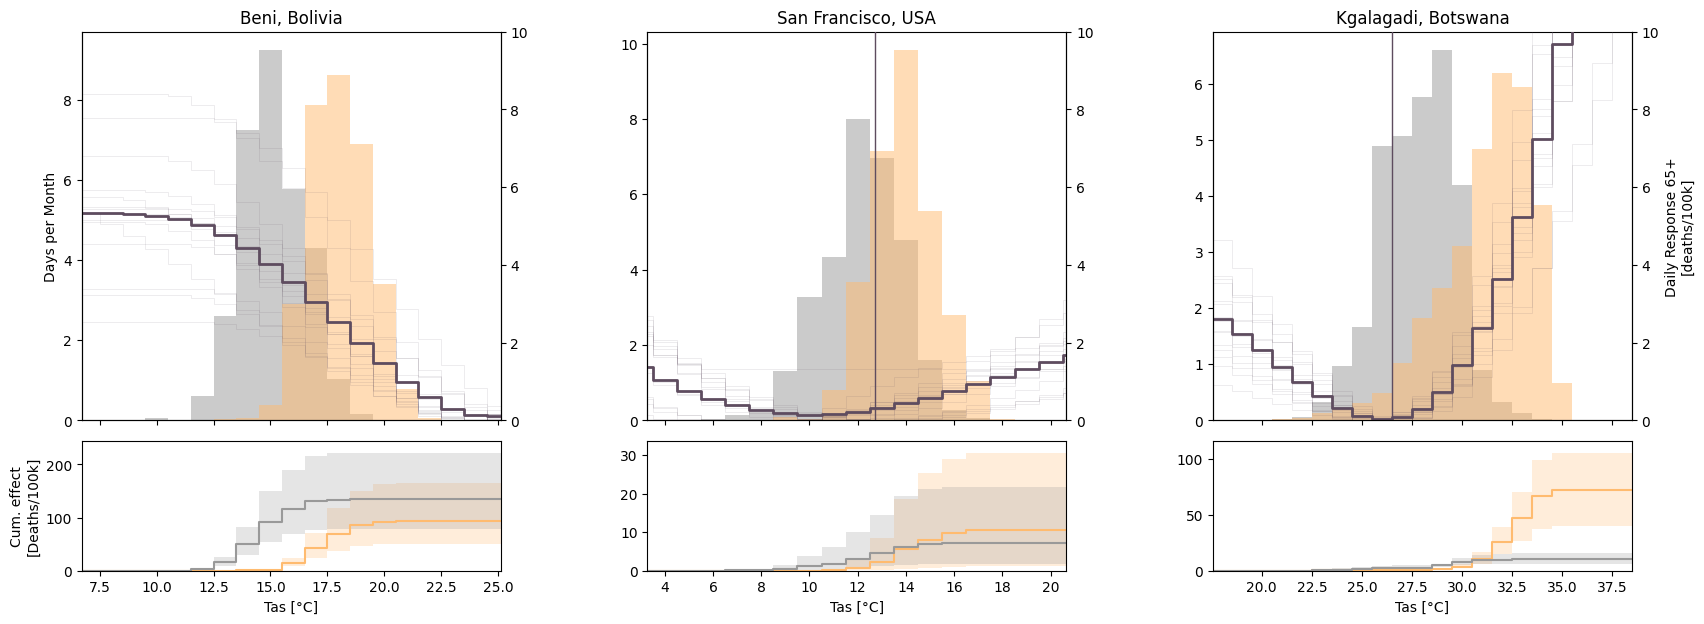

In [51]:
fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(1, 3, wspace=0.35)

regions = {
    "BOL.2.16.45": "Beni, Bolivia",
    "USA.5.221": "San Francisco, USA",
    "BWA.3": "Kgalagadi, Botswana",
}

for i, (region, name) in enumerate(regions.items()):
    plot_region_panel(fig, gs[i], region, title=name,
                      show_left_labels=(i == 0),
                      show_right_labels=(i == len(regions) - 1))

In [ ]:
# Find good regions to plot
impact = analysis_utils.compute_impact(effect.chunk({dim: -1 for dim in config.dims}), 
                                        config,
                                        ensemble=True).sel(month = 1)

region_mask = (impact.mean(dim = config.dims) >= 4) & (impact.mean(dim = config.dims) <= 5) 
selected_regions = impact['region'].values[region_mask.values]

In [47]:
selected_regions

array(['ARG.13.334', 'ARG.14.337', 'ARG.14.339', 'ARG.14.341',
       'ARG.14.344', 'ARG.14.349', 'ARG.14.350',
       'ARG.14.R54e5121922cc6fa2', 'ARG.24.493', 'ARG.24.494',
       'ARG.7.218', 'ARG.7.222', 'AUS.11.1322', 'AUS.11.1333',
       'AUS.11.1348', 'AUS.11.1351', 'AUS.11.1386', 'AUS.5.361',
       'AUS.5.387', 'AUS.6.815', 'AUS.8.1010', 'AUS.8.1011', 'AUS.8.1012',
       'AUS.8.1013', 'AUS.8.1014', 'AUS.8.1020', 'AUS.8.1023',
       'AUS.8.1028', 'AUS.8.1038', 'AUS.8.1039', 'AUS.8.1042',
       'AUS.8.1043', 'BFA.10', 'BFA.27', 'BFA.28', 'BFA.3',
       'BOL.8.78.261', 'BOL.8.78.264', 'BOL.8.80.271', 'BOL.8.81.280',
       'BOL.8.82.281', 'BOL.8.82.282', 'BOL.8.89.305',
       'BRA.11.1343.Rc9ee20d28d96b4b6', 'BRA.11.1349.2749',
       'BRA.11.1370.2800', 'BRA.11.1370.R8d56035b61f6e47c',
       'BRA.11.1380.2832', 'BRA.13.1560.3166', 'BRA.13.1595.3229',
       'BRA.13.1595.R77a9143226524757', 'BRA.13.1611.3277',
       'BRA.13.1611.R72c2b47bdd6429f5', 'BRA.13.1777.3588',
   